In [ ]:
import decoupler as dc
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

sc.set_figure_params(figsize=(3, 3), frameon=False)

SEED = 2026
np.random.seed(SEED)

c:\Users\asd123cheese\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


decoupler version: 2.2.0


In [ ]:
msigdb = dc.op.resource("MSigDB", organism="mouse")

In [ ]:
COLLECTIONS = ["hallmark", "go_biological_process", "reactome_pathways"]

net = msigdb.query("collection in @COLLECTIONS")
print("collections loaded:")
print(net["collection"].value_counts().to_string())

# Filter duplicates
net = net[~net.duplicated(("geneset", "genesymbol"))]
net = net.rename(columns={"geneset": "source", "genesymbol": "target"})

collections loaded:
collection
go_biological_process    613023
reactome_pathways         98063
hallmark                   7678


In [ ]:
geneset_size = net.groupby("source").size()
valid_pathways = geneset_size[(geneset_size >= 10) & (geneset_size <= 500)].index

kept = net["source"].isin(valid_pathways)
print("kept sources per collection:")
print(net[kept].groupby("collection")["source"].nunique().to_string())
print(f"total kept pathways: {net.loc[kept, 'source'].nunique()}")

net = net[kept]

kept sources per collection:
collection
go_biological_process    5255
hallmark                   50
reactome_pathways        1405
total kept pathways: 6710


In [59]:
import pickle

# dict，key = (tissue, celltype)，value = 含 variable/stat/log_fc/adj_p_value 列的 DataFrame。
with open("../all_results.pkl", "rb") as f:
    results = pickle.load(f)

print(f"loaded {len(results)} nodes: {list(results.keys())}")

loaded 8 nodes: [('Kidney', 'lymphoid'), ('Kidney', 'myeloid/macrophage'), ('Liver', 'lymphoid'), ('Liver', 'myeloid/macrophage'), ('Lung', 'lymphoid'), ('Lung', 'myeloid/macrophage'), ('spleen/marrow', 'lymphoid'), ('spleen/marrow', 'myeloid/macrophage')]


In [60]:
#  2) 有限值清洗：decoupler 2.x 会对 mat 做有限值断言，
#     NaN/inf 会直接抛 AssertionError（原实现在转置后过滤，语义正确但位置易漏，
#     这里改为在构造向量时就用 np.isfinite 显式过滤，并打印丢弃基因数）。
#  3) 置换检验：times 控制随机排列次数（经 **kwargs 透传）。
#     2.x 中必须 times>1 才会得到有意义的经验 p 值/BH 校正，
#     因此显式设置 times=1000 并固定 seed，保证可复现。
#  4) 输入形状：GSEA 期望“每个样本一行的特征统计向量”。
#     这里每个节点只有一个对比（young vs old），故构造 1 x n_genes 的 DataFrame。
TIMES = 1000  # GSEA 置换次数

scores = {}

for key, res_df in results.items():
    res_df = res_df.set_index("variable")

    # --- 排序指标：Wald stat ---
    rank_stat = res_df["stat"]
    finite = np.isfinite(rank_stat)
    n_drop = int((~finite).sum())
    if n_drop:
        print(f"{key}: dropped {n_drop} non-finite genes")
    rank_stat = rank_stat[finite]

    data = rank_stat.to_frame("young vs old").T

    score, padj = dc.mt.gsea(
        data=data,
        net=net,
        times=TIMES,
        seed=SEED,
    )

    mask = (padj.T < 0.01).iloc[:, 0]
    scores[key] = score.loc[:, mask]

    print(f"{key}: {int(mask.sum())} significant pathways (FDR<0.01) / {score.shape[1]}")

rows = []
for (tissue, celltype), df in scores.items():
    tmp = df.T.reset_index()
    tmp.columns = ["pathway", "score"]
    tmp["tissue"] = tissue
    tmp["celltype"] = celltype
    rows.append(tmp)

gsea_long = pd.concat(rows, ignore_index=True)
gsea = gsea_long.pivot(index="pathway", columns=["tissue", "celltype"], values="score")
gsea.insert(0, "collection", gsea.index.to_series().map(
    net.drop_duplicates("source").set_index("source")["collection"]
).values)
print(f"\nGSEA matrix: {gsea.shape}")

('Kidney', 'lymphoid'): dropped 6 non-finite genes
('Kidney', 'lymphoid'): 218 significant pathways (FDR<0.01) / 6156
('Kidney', 'myeloid/macrophage'): dropped 17 non-finite genes
('Kidney', 'myeloid/macrophage'): 198 significant pathways (FDR<0.01) / 6154
('Liver', 'lymphoid'): dropped 50 non-finite genes
('Liver', 'lymphoid'): 230 significant pathways (FDR<0.01) / 6150
('Liver', 'myeloid/macrophage'): dropped 31 non-finite genes
('Liver', 'myeloid/macrophage'): 426 significant pathways (FDR<0.01) / 6151
('Lung', 'lymphoid'): dropped 49 non-finite genes
('Lung', 'lymphoid'): 168 significant pathways (FDR<0.01) / 6147
('Lung', 'myeloid/macrophage'): dropped 13 non-finite genes
('Lung', 'myeloid/macrophage'): 281 significant pathways (FDR<0.01) / 6155
('spleen/marrow', 'lymphoid'): dropped 7 non-finite genes
('spleen/marrow', 'lymphoid'): 350 significant pathways (FDR<0.01) / 6155
('spleen/marrow', 'myeloid/macrophage'): dropped 9 non-finite genes
('spleen/marrow', 'myeloid/macrophage')

In [61]:
# ===================== ORA（decoupler 2.x） =====================
# 【改动说明】
#  1) 输入：ORA 期望“二值化/指示”矩阵。这里对每个节点构造 1 x n_genes 的 0/1 向量，
#     FDR<0.05 的基因为 1，其余为 0（与原实现一致）。
#  2) tmin 自适应：ORA 会对“与 net 共享靶基因数 <= tmin”的 source 抛
#     AssertionError（2.x 行为与 1.x 一致，已实测）。
#     原实现在失败时直接 SKIP 整个节点，会丢失大量节点。
#     这里改为**逐级降低 tmin 重试**（5 -> 3 -> 2），尽量保留节点；
#     仍失败才记录跳过，并打印原因。
#  3) 有限值：ORA 输入为 0/1 整数矩阵，天然有限，无需额外清洗，
#     但仍显式校验，避免上游改动引入 NaN。
ora_scores = {}
tmin_map = {}
ora_skipped = {}

for key, res_df in results.items():
    res_df = res_df.set_index("variable")
    all_genes = res_df.index
    sig_genes = res_df.index[res_df["adj_p_value"] < 0.01]

    vec = pd.DataFrame(0, index=["young vs old"], columns=all_genes)
    vec.loc["young vs old", sig_genes] = 1
    vec = vec.loc[:, np.isfinite(vec.iloc[0])]

    # --- 逐级降 tmin 重试 ---
    score = padj = None
    used_tmin = None
    for tmin in (5, 3, 2):
        if tmin > len(sig_genes):
            continue
        try:
            score, padj = dc.mt.ora(data=vec, net=net, tmin=tmin)
            used_tmin = tmin
            break
        except AssertionError:
            continue

    if score is None:
        ora_skipped[key] = len(sig_genes)
        print(f"SKIP {key}: sig_genes={len(sig_genes)} (all tmin failed)")
        continue

    mask = (padj.T < 0.01).iloc[:, 0]
    ora_scores[key] = score.loc[:, mask]
    tmin_map[key] = used_tmin

print("tmin used per node:", tmin_map)
print("skipped nodes:", ora_skipped)

rows = []
for (tissue, celltype), df in ora_scores.items():
    tmp = df.T.reset_index()
    tmp.columns = ["pathway", "score"]
    tmp["tissue"] = tissue
    tmp["celltype"] = celltype
    rows.append(tmp)

ora_long = pd.concat(rows, ignore_index=True)
ora = ora_long.pivot(index="pathway", columns=["tissue", "celltype"], values="score")
ora.insert(0, "collection", ora.index.to_series().map(
    net.drop_duplicates("source").set_index("source")["collection"]
).values)
print(f"\nORA matrix: {ora.shape}")

SKIP ('Liver', 'lymphoid'): sig_genes=0 (all tmin failed)
tmin used per node: {('Kidney', 'lymphoid'): 5, ('Kidney', 'myeloid/macrophage'): 5, ('Liver', 'myeloid/macrophage'): 5, ('Lung', 'lymphoid'): 5, ('Lung', 'myeloid/macrophage'): 5, ('spleen/marrow', 'lymphoid'): 5, ('spleen/marrow', 'myeloid/macrophage'): 2}
skipped nodes: {('Liver', 'lymphoid'): 0}

ORA matrix: (499, 8)


In [62]:
gsea_hallmark = gsea[gsea["collection"] == "hallmark"]
gsea_reactome = gsea[gsea["collection"] == "reactome_pathways"]
gsea_gobp     = gsea[gsea["collection"] == "go_biological_process"]
ora_hallmark = ora[ora["collection"] == "hallmark"]
ora_reactome = ora[ora["collection"] == "reactome_pathways"]
ora_gobp     = ora[ora["collection"] == "go_biological_process"]

In [63]:
both_hallmark = gsea_hallmark.loc[[p for p in gsea_hallmark.index if p in ora_hallmark.index]]
both_reactome = gsea_reactome.loc[[p for p in gsea_reactome.index if p in ora_reactome.index]]
both_gobp     = gsea_gobp.loc[[p for p in gsea_gobp.index if p in ora_gobp.index]]

both_hallmark.to_csv("../gsea_ora_both_hallmark.tsv", sep="\t")
both_reactome.to_csv("../gsea_ora_both_reactome.tsv", sep="\t")
both_gobp.to_csv("../gsea_ora_both_gobp.tsv", sep="\t")

In [64]:
both_hallmark_lymphoid = both_hallmark.xs("lymphoid", level="celltype", axis=1).dropna(how="all")
both_hallmark_myeloid  = both_hallmark.xs("myeloid/macrophage", level="celltype", axis=1).dropna(how="all")

print("hallmark ∩ GSEA ∩ ORA")
print(f"  lymphoid: {both_hallmark_lymphoid.shape}")
print(f"  myeloid : {both_hallmark_myeloid.shape}")

print("\nlymphoid 通路:")
print(both_hallmark_lymphoid.index.tolist())
print("\nmyeloid 通路:")
print(both_hallmark_myeloid.index.tolist())

hallmark ∩ GSEA ∩ ORA
  lymphoid: (19, 4)
  myeloid : (23, 4)

lymphoid 通路:
['HALLMARK_ADIPOGENESIS', 'HALLMARK_APICAL_JUNCTION', 'HALLMARK_APOPTOSIS', 'HALLMARK_E2F_TARGETS', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_ESTROGEN_RESPONSE_EARLY', 'HALLMARK_HEME_METABOLISM', 'HALLMARK_HYPOXIA', 'HALLMARK_IL2_STAT5_SIGNALING', 'HALLMARK_IL6_JAK_STAT3_SIGNALING', 'HALLMARK_INFLAMMATORY_RESPONSE', 'HALLMARK_INTERFERON_GAMMA_RESPONSE', 'HALLMARK_KRAS_SIGNALING_UP', 'HALLMARK_MYC_TARGETS_V1', 'HALLMARK_MYOGENESIS', 'HALLMARK_OXIDATIVE_PHOSPHORYLATION', 'HALLMARK_P53_PATHWAY', 'HALLMARK_TNFA_SIGNALING_VIA_NFKB', 'HALLMARK_XENOBIOTIC_METABOLISM']

myeloid 通路:
['HALLMARK_ADIPOGENESIS', 'HALLMARK_ALLOGRAFT_REJECTION', 'HALLMARK_APOPTOSIS', 'HALLMARK_COAGULATION', 'HALLMARK_COMPLEMENT', 'HALLMARK_E2F_TARGETS', 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION', 'HALLMARK_ESTROGEN_RESPONSE_EARLY', 'HALLMARK_ESTROGEN_RESPONSE_LATE', 'HALLMARK_FATTY_ACID_METABOLISM', 'HALLMARK_HEME_METABOLISM',

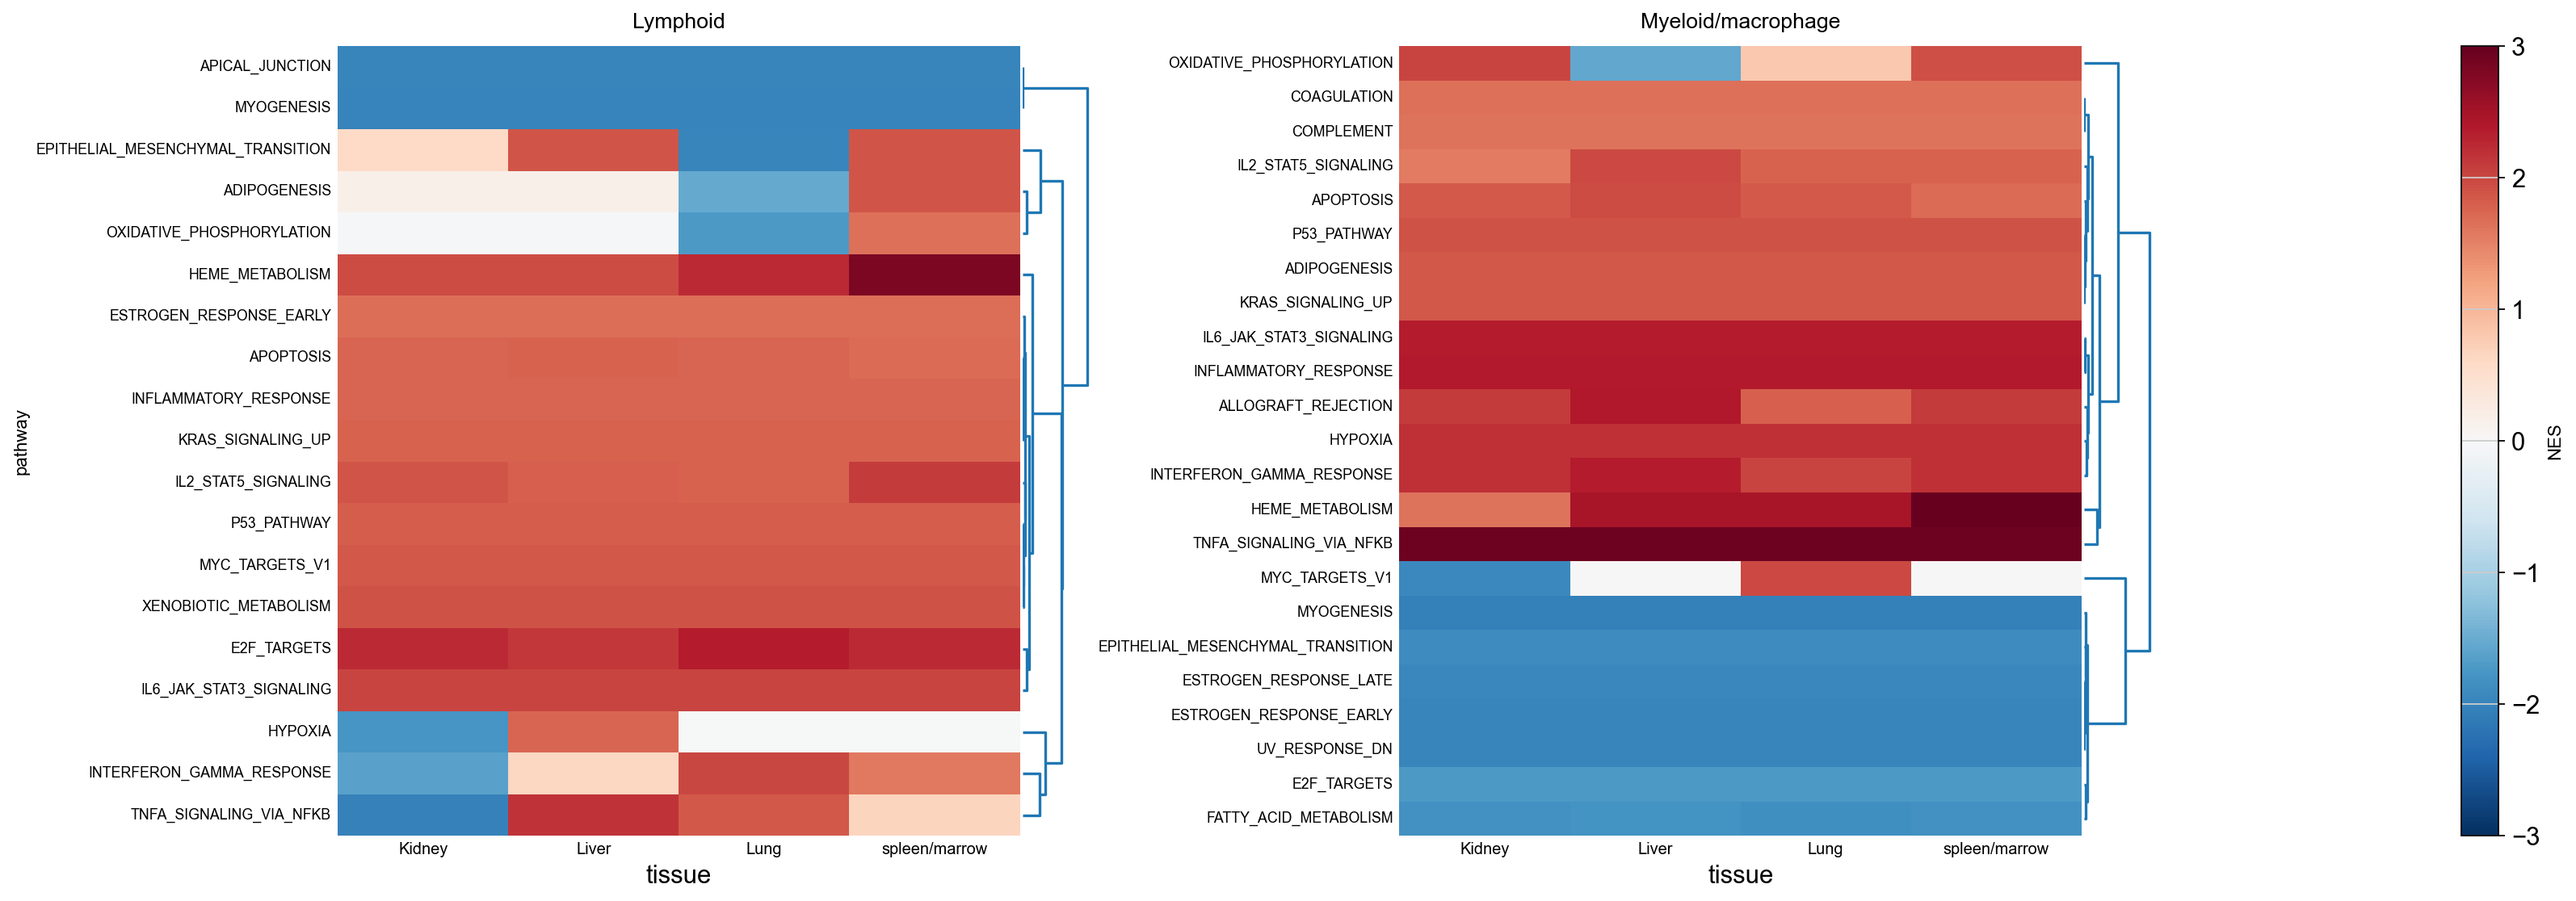

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np

mpl.rcParams["patch.linewidth"] = 0
mpl.rcParams["patch.edgecolor"] = "none"

def prep(mat):
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.apply(lambda r: r.fillna(r.mean()), axis=1).fillna(0)
    row_link = linkage(mat.values, method="average", metric="euclidean")
    row_order = dendrogram(row_link, no_plot=True)["leaves"]
    return mat.iloc[row_order], row_link

lym, lym_link = prep(both_hallmark_lymphoid)
mye, mye_link = prep(both_hallmark_myeloid)

H = 0.28 * max(len(lym), len(mye)) + 1.5

fig = plt.figure(figsize=(19, H))
gs = GridSpec(
    1, 3,
    width_ratios=[1, 1, 0.05],
    wspace=0.6,
    left=0.06, right=0.94, top=0.92, bottom=0.15,
)

def draw(ax, mat, link, title, show_ylabel):
    sns.heatmap(
        mat,
        cmap="RdBu_r", center=0, vmin=-3, vmax=3,
        cbar=False,
        yticklabels=mat.index,
        xticklabels=mat.columns,
        ax=ax,
        linewidths=0, linecolor="none",
    )
    for c in ax.collections:
        c.set_edgecolor("face")
        c.set_linewidth(0)
        c.set_antialiased(False)
    ax.grid(False)
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_yticklabels(
        [t.get_text().replace("HALLMARK_", "") for t in ax.get_yticklabels()],
        fontsize=8, rotation=0,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=9)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_ylabel("pathway" if show_ylabel else "", fontsize=10)

    divider = make_axes_locatable(ax)
    ax_dend = divider.append_axes("right", size="10%", pad=0.02)
    dendrogram(
        link, ax=ax_dend,
        orientation="right",
        no_labels=True,
        color_threshold=0,
    )
    ax_dend.invert_yaxis()
    ax_dend.axis("off")

ax1 = fig.add_subplot(gs[0, 0])
draw(ax1, lym, lym_link, "Lymphoid", show_ylabel=True)

ax2 = fig.add_subplot(gs[0, 1])
draw(ax2, mye, mye_link, "Myeloid/macrophage", show_ylabel=False)

# 右侧色条
ax_cb = fig.add_subplot(gs[0, 2])
norm = plt.Normalize(vmin=-3, vmax=3)
cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="RdBu_r"), cax=ax_cb)
cb.set_label("NES", fontsize=10)

plt.show()